In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from aqua.core.graphics import plot_single_map_diff, ConfigStyle
from aqua.core.logger import log_configure

In [2]:
# Import results from the biases_production.ipynb notebook
folder = "/work/users/mnurisso/DestinE_paper/Figure4/netcdf"

icon_file_mask = f"{folder}/*ICON*.nc"
ifs_nemo_file_mask = f"{folder}/*IFS-NEMO*.nc"
ifs_fesom_file_mask = f"{folder}/*IFS-FESOM*.nc"
era5_file_mask = f"{folder}/*ERA5*.nc"

icon_climatology = xr.open_mfdataset(icon_file_mask)
ifs_nemo_climatology = xr.open_mfdataset(ifs_nemo_file_mask)
ifs_fesom_climatology = xr.open_mfdataset(ifs_fesom_file_mask)
era5_climatology = xr.open_mfdataset(era5_file_mask)

In [3]:
var = 'u'
loglevel = 'INFO'
titles = ['cycle o25.1 ICON historical', 'cycle o25.1 IFS-NEMO historical', 'cycle o25.1 IFS-FESOM historical']
suptitle = 'Global bias of Zonal Wind Speed at 850 hPa (m/s) \n with respect to ERA5 climatology (1990-2015)'
cbar_label = 'Zonal Wind Speed (m/s)'

In [16]:
def plot_biases(models: list, ref: xr.DataArray, var: str,
                suptitle: str, titles: list,
                vmin_fill: float, vmax_fill: float,
                vmin_contour: float, vmax_contour: float,
                cbar_label: str,
                cmap: str, folder: str = './figures',
                loglevel: str = 'INFO'):
    """
    Plot biases of different models with respect to a reference dataset.

    Args:
        models (list): List of model datasets.
        ref (xr.DataArray): Reference dataset.
        var (str): Variable to plot.
        folder (str): Folder to save the plots.
        vmin_fill (float): Minimum value for fill color scale.
        vmax_fill (float): Maximum value for fill color scale.
        vmin_contour (float): Minimum value for contour color scale.
        vmax_contour (float): Maximum value for contour color scale.
        cmap (str): Colormap to use.
        loglevel (str): Logging level.
    """
    # Set logger
    logger = log_configure(loglevel, 'plot_biases')

    # Configure AQUA plot style
    ConfigStyle(loglevel=loglevel)

    # Create figure
    nrows = len(models)
    ncols = 1
    figsize = (8, 4 * nrows)
    fig = plt.figure(figsize=figsize)

    for i, model in enumerate(models, 1):
        data = model[var]

        logger.debug(f"Plotting {data}")

        fig, ax = plot_single_map_diff(
            data=data,
            data_ref=ref[var],
            fig=fig,
            ax_pos=(nrows, ncols, i),
            cmap=cmap, title=titles[i - 1],
            vmin_fill=vmin_fill, vmax_fill=vmax_fill,
            vmin_contour=vmin_contour, vmax_contour=vmax_contour,
            return_fig=True, cbar=False, sym=False,
            loglevel=loglevel
        )

    # Adjust the location of the subplots on the page to make room for the colorbar
    fig.subplots_adjust(bottom=0.25, top=0.9, left=0.05, right=0.95,
                        wspace=0.1, hspace=0.2)

    # Add a colorbar axis at the bottom of the graph
    cbar_ax = fig.add_axes([0.2, 0.15, 0.6, 0.03])
    mappable = ax.collections[0]

    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal',
                        label=cbar_label)

    cbar.set_ticks(np.linspace(vmin_fill, vmax_fill, 11 + 1))

    fig.suptitle(suptitle, fontsize=16)

    # Save figure
    output_file = f"{folder}/zonal_wind_speed_850hPa_biases.pdf"
    fig.savefig(output_file)
    logger.info(f"Figure saved to {output_file}")

2026-01-27 15:48:09 :: plot_biases :: INFO     -> Figure saved to ./figures/zonal_wind_speed_850hPa_biases.pdf


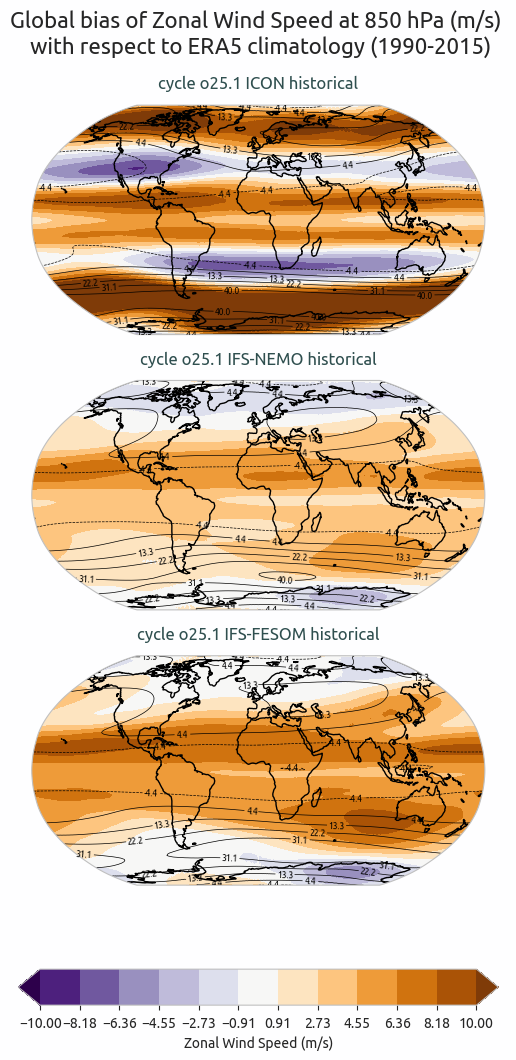

In [24]:
plot_biases(
    models=[icon_climatology, ifs_nemo_climatology, ifs_fesom_climatology],
    ref=era5_climatology,
    var=var,
    vmin_fill=-10.0,
    vmax_fill=10.0,
    vmin_contour=-40.0,
    vmax_contour=40.0,
    cmap='PuOr_r',
    titles=titles,
    suptitle=suptitle,
    cbar_label=cbar_label,
    loglevel=loglevel
)